# 07 – Neural Network (MLP)

Evaluates a Multi-Layer Perceptron as a comparator to the best traditional models from Notebook 06. An architecture search across three network sizes is performed first, followed by hyperparameter tuning on the best architecture — covering activation functions, optimisers, regularisation, learning rate, and batch size. Results are compared against all Notebook 06 models to address **RQ1**: *To what extent do neural network models compare to traditional machine learning models in predicting customer churn, and how does hyperparameter optimisation influence their relative performance?*

**Inputs:** Preprocessed features from Notebook 02 · Full model comparison from Notebook 06

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

## Load Processed Data

Preprocessed features and binary target labels loaded from Notebook 02 outputs.

In [2]:
X = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (51047, 50)
Target shape:   (51047,)


## Train–Test Split

Same 80/20 stratified split with `random_state=42` as all previous notebooks, ensuring the test set is identical and results are directly comparable.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (40837, 50)
Test set:     (10210, 50)


## Apply Random Under-Sampling Within Cross-Validation

Under-sampling is wrapped inside an `imblearn.Pipeline` alongside the model. This ensures that resampling is applied only within each training fold during cross-validation — the validation fold always retains the original class distribution, preventing the CV scores from being inflated by artificially balanced validation data.

In [4]:
# Under-sampling is now handled inside each model's ImbPipeline — no standalone resampling step needed.
print("Under-sampling will be applied within each CV fold via ImbPipeline.")

Under-sampling will be applied within each CV fold via ImbPipeline.


## Evaluation Function

Same function used across Notebooks 03–06 for consistent metric computation.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    """Evaluate a fitted classifier and print a formatted results summary."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    cm        = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"=== {name} ===")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"], zero_division=0))

    return {
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1-score":  round(f1, 4),
        "ROC-AUC":   round(roc_auc, 4),
        "Confusion Matrix": cm
    }

## Architecture Search

Three network depths are compared using 3-fold stratified cross-validation on the training set — the test set is not touched at this stage, keeping the final evaluation fully unbiased. All variants use ReLU activation, Adam optimiser, and L2 regularisation (`alpha=0.001`). Early stopping is enabled (`early_stopping=True`, `n_iter_no_change=10`) with a 10% internal validation split. This is safe here because under-sampling is applied inside the pipeline before the MLP sees any data — the internal validation fraction is therefore drawn from the already-balanced training set, so early stopping does not stall on imbalanced data.

In [6]:
from sklearn.model_selection import cross_val_score

architectures = {
    "MLP (64, 32)":        (64, 32),
    "MLP (128, 64, 32)":   (128, 64, 32),
    "MLP (256, 128, 64)":  (256, 128, 64),
}

cv_arch = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
arch_results = {}

for name, layers in architectures.items():
    pipe_mlp = ImbPipeline([
        ("undersample", RandomUnderSampler(random_state=42)),
        ("model", MLPClassifier(
            hidden_layer_sizes=layers,
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=256,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42
        ))
    ])
    scores = cross_val_score(pipe_mlp, X_train, y_train, cv=cv_arch, scoring="f1", n_jobs=-1)
    arch_results[name] = {"CV F1 Mean": round(scores.mean(), 4), "CV F1 Std": round(scores.std(), 4)}
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

arch_summary = pd.DataFrame(arch_results).T
print("\n=== Architecture Comparison (3-fold CV on training set) ===")
print(arch_summary.to_string())

best_arch_name   = arch_summary["CV F1 Mean"].idxmax()
best_arch_layers = architectures[best_arch_name]
print(f"\nBest architecture: {best_arch_name} {best_arch_layers}")

MLP (64, 32): F1 = 0.4501 ± 0.0038
MLP (128, 64, 32): F1 = 0.4550 ± 0.0078
MLP (256, 128, 64): F1 = 0.4652 ± 0.0130

=== Architecture Comparison (3-fold CV on training set) ===
                    CV F1 Mean  CV F1 Std
MLP (64, 32)            0.4501     0.0038
MLP (128, 64, 32)       0.4550     0.0078
MLP (256, 128, 64)      0.4652     0.0130

Best architecture: MLP (256, 128, 64) (256, 128, 64)


## Hyperparameter Tuning

RandomizedSearchCV is applied to the best architecture (MLP 256→128→64), searching over:

- **Activation function** (`relu`, `tanh`, `logistic`) — controls the non-linearity applied at each neuron
- **Solver/optimiser** (`adam`, `sgd`) — determines the weight update strategy
- **L2 regularisation** (`alpha`) — penalises large weights to reduce overfitting
- **Initial learning rate** (`learning_rate_init`) — step size for weight updates
- **Batch size** — number of samples per gradient update

F1-score is used as the optimisation metric, consistent with Notebooks 05 and 06. The search runs for 20 iterations with 5-fold stratified cross-validation.

## Baseline MLP Evaluation

Before tuning, the best architecture (MLP 256→128→64) is evaluated on the test set using sklearn's default parameters (`relu` activation, `adam` solver, `alpha=0.0001`). Note that the architecture search used `alpha=0.001` as a fixed value — this baseline uses the true sklearn defaults to represent an out-of-the-box MLP, providing a concrete before/after comparison to quantify the effect of hyperparameter optimisation.

In [7]:
pipe_mlp_default = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", MLPClassifier(
        hidden_layer_sizes=best_arch_layers,
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])
pipe_mlp_default.fit(X_train, y_train)

mlp_default_results = evaluate_model("MLP (Default)", pipe_mlp_default, X_test, y_test)

=== MLP (Default) ===
  Precision : 0.3743
  Recall    : 0.5663
  F1-score  : 0.4507
  ROC-AUC   : 0.6245
  Confusion Matrix:
    TN=4483  FP=2785
    FN=1276  TP=1666


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.78      0.62      0.69      7268
       Churn       0.37      0.57      0.45      2942

    accuracy                           0.60     10210
   macro avg       0.58      0.59      0.57     10210
weighted avg       0.66      0.60      0.62     10210



In [8]:
pipe_mlp_tune = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", MLPClassifier(
        hidden_layer_sizes=best_arch_layers,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])

param_dist = {
    "model__activation":         ["relu", "tanh", "logistic"],
    "model__solver":             ["adam", "sgd"],
    "model__alpha":              [0.0001, 0.001, 0.01, 0.1],
    "model__learning_rate_init": [0.0005, 0.001, 0.005, 0.01],
    "model__batch_size":         [64, 128, 256],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe_mlp_tune,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1: ", round(search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__solver': 'adam', 'model__learning_rate_init': 0.01, 'model__batch_size': 64, 'model__alpha': 0.001, 'model__activation': 'logistic'}
Best CV F1:  0.4769


## Training the Final MLP

The best configuration found by the search is retrained on the full resampled training set. The loss curve confirms convergence before evaluation on the held-out test set.

In [9]:
mlp_final_pipe = search.best_estimator_
mlp_final = mlp_final_pipe.named_steps["model"]

print(f"Architecture : {best_arch_layers}")
print(f"Best params  : {search.best_params_}")
print(f"Training iterations: {mlp_final.n_iter_}")
print(f"Final training loss: {mlp_final.loss_:.4f}")

Architecture : (256, 128, 64)
Best params  : {'model__solver': 'adam', 'model__learning_rate_init': 0.01, 'model__batch_size': 64, 'model__alpha': 0.001, 'model__activation': 'logistic'}
Training iterations: 36
Final training loss: 0.6267


## Training Loss Curve

A steady decline to a plateau indicates convergence. Premature flattening would suggest the model is underfitting; continued decrease to very low values suggests overfitting on the resampled training set.

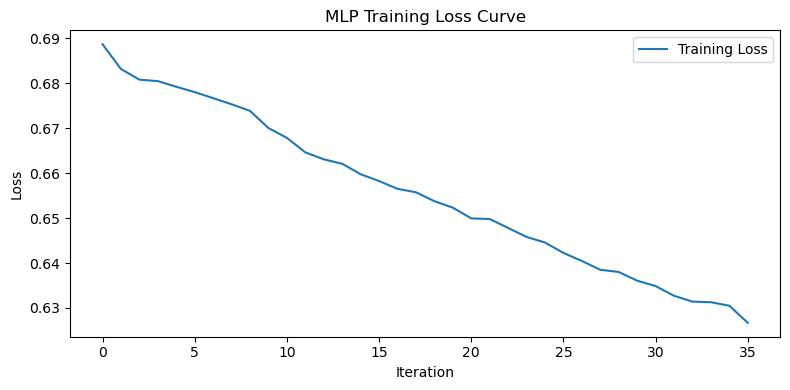

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_final.loss_curve_, label="Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Final MLP Evaluation

The tuned MLP is evaluated on the held-out 20% test set — unseen during both training and the hyperparameter search.

In [11]:
mlp_results = evaluate_model("MLP (Tuned)", mlp_final_pipe, X_test, y_test)

=== MLP (Tuned) ===
  Precision : 0.3598
  Recall    : 0.6264
  F1-score  : 0.4571
  ROC-AUC   : 0.6295
  Confusion Matrix:
    TN=3989  FP=3279
    FN=1099  TP=1843


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.78      0.55      0.65      7268
       Churn       0.36      0.63      0.46      2942

    accuracy                           0.57     10210
   macro avg       0.57      0.59      0.55     10210
weighted avg       0.66      0.57      0.59     10210



## Comparison Against All Models

The full results from Notebook 06 are loaded and the tuned MLP result is appended, providing a complete cross-model comparison.

In [12]:
nb06_results = pd.read_csv(PROCESSED_DIR / "notebook06_full_results.csv", index_col=0)

mlp_default_row = pd.DataFrame([{
    "Precision": mlp_default_results["Precision"],
    "Recall":    mlp_default_results["Recall"],
    "F1-score":  mlp_default_results["F1-score"],
    "ROC-AUC":   mlp_default_results["ROC-AUC"]
}], index=["MLP (Default)"])

mlp_tuned_row = pd.DataFrame([{
    "Precision": mlp_results["Precision"],
    "Recall":    mlp_results["Recall"],
    "F1-score":  mlp_results["F1-score"],
    "ROC-AUC":   mlp_results["ROC-AUC"]
}], index=["MLP (Tuned)"])

full_comparison = pd.concat([nb06_results, mlp_default_row, mlp_tuned_row])

print("=== Full Model Comparison ===")
print(full_comparison.to_string())

mlp_tuned_row.to_csv(PROCESSED_DIR / "notebook07_results.csv")
print("\nMLP (Tuned) results saved to:", PROCESSED_DIR / "notebook07_results.csv")

=== Full Model Comparison ===
                             Precision  Recall  F1-score  ROC-AUC
Logistic Regression (Tuned)     0.3599  0.5744    0.4425   0.6122
Decision Tree (Tuned)           0.3756  0.5421    0.4437   0.6243
Random Forest (Tuned)           0.3763  0.6917    0.4874   0.6576
XGBoost (Default)               0.3819  0.6254    0.4742   0.6507
XGBoost (Tuned)                 0.3887  0.6601    0.4893   0.6688
MLP (Default)                   0.3743  0.5663    0.4507   0.6245
MLP (Tuned)                     0.3598  0.6264    0.4571   0.6295

MLP (Tuned) results saved to: /Users/abbasq/Uni/third-year/IP/data/processed/notebook07_results.csv


## Key Observations — RQ1

**Architecture search results (3-fold CV F1):**

| Architecture | CV F1 Mean | CV F1 Std |
|---|---|---|
| MLP (64, 32) | 0.4501 | ±0.0038 |
| MLP (128, 64, 32) | 0.4550 | ±0.0078 |
| **MLP (256, 128, 64)** | **0.4652** | **±0.0130** |

MLP (256, 128, 64) achieved the highest CV F1 and was selected for tuning. The larger architecture benefits from greater capacity to capture non-linear interactions in the 50-feature space.

**Hyperparameter tuning — effect on performance:**

The expanded search covered activation function (`relu`, `tanh`, `logistic`), solver (`adam`, `sgd`), L2 regularisation (`alpha`), learning rate, and batch size. The best configuration was: `activation=logistic`, `solver=adam`, `learning_rate_init=0.01`, `batch_size=64`, `alpha=0.001` (CV F1: 0.4769). Notably, `logistic` activation outperformed `relu` — suggesting that a sigmoid-style non-linearity better fits the decision boundaries in this tabular churn dataset. Tuning improved test set F1 from 0.4507 (default) to 0.4571 (tuned) and recall from 0.5663 to 0.6264, demonstrating a meaningful impact on the model's ability to identify churners.

**Full model comparison (test set):**

| Model | Precision | Recall | F1-score | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression (Tuned) | 0.3599 | 0.5744 | 0.4425 | 0.6122 |
| Decision Tree (Tuned) | 0.3756 | 0.5421 | 0.4437 | 0.6243 |
| MLP (Default) | 0.3743 | 0.5663 | 0.4507 | 0.6245 |
| MLP (Tuned) | 0.3598 | 0.6264 | 0.4571 | 0.6295 |
| XGBoost (Default) | 0.3819 | 0.6254 | 0.4742 | 0.6507 |
| Random Forest (Tuned) | 0.3763 | 0.6917 | 0.4874 | 0.6576 |
| **XGBoost (Tuned)** | **0.3887** | **0.6601** | **0.4893** | **0.6688** |

**Addressing RQ1:** The tuned MLP (F1: 0.4571, ROC-AUC: 0.6295) outperforms Logistic Regression and Decision Tree but falls below Random Forest (Tuned) and XGBoost (Tuned). Hyperparameter optimisation — particularly activation function choice — meaningfully improved MLP performance, though the gap with the best tree-based model remains. This is consistent with Grinsztajn et al. (2022), who show that gradient-boosted trees consistently outperform neural networks on structured tabular data. **XGBoost (Tuned) remains the best model overall.**